# Chronos-2 trading features with native REINFORCE

This notebook shows the two Chronos workflows supported by `crosslearn`:

1. online extraction with `ChronosExtractor`
2. offline precomputation with `build_offline_bundle`

`gym-anytrading` stays outside the package extras on purpose, so install it directly at the notebook level.
            

In [ ]:
# Uncomment in a fresh environment:
# %pip install "crosslearn[chronos]" gym-anytrading pandas matplotlib      

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gym_anytrading.datasets import STOCKS_GOOGL
from gym_anytrading.envs import StocksEnv

from crosslearn import REINFORCE, make_vec_env
from crosslearn.extractors import ChronosExtractor, build_offline_bundle

# Get gym-anytrading version from metadata
try:
    import importlib.metadata
    ga_version = importlib.metadata.version("gym-anytrading")
    print(f"gym-anytrading version: {ga_version}") #>> gym-anytrading version: 2.0.0
except importlib.metadata.PackageNotFoundError:
    print("gym-anytrading not found")

gym-anytrading version: 2.0.0


## Dataset and rolling-window setup

The raw environment emits rolling OHLCV windows. `ChronosExtractor` can embed those windows online, while `build_offline_bundle(...)` can precompute the same representation into aligned dataframe columns ahead of training.
            

In [3]:
LOOKBACK = 30
FEATURE_COLUMNS = ['Open', 'High', 'Low', 'Close', 'Volume']
SELECTED_COLUMNS = ['Close', 'Volume']
FRAME_BOUND = (LOOKBACK, len(STOCKS_GOOGL))

display(STOCKS_GOOGL.head())
print('Frame bound:', FRAME_BOUND)
print('Feature columns:', FEATURE_COLUMNS)
print('Chronos-selected columns:', SELECTED_COLUMNS) 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-05-22,198.528534,199.524521,196.196198,196.946945,196.946945,3433700
2009-05-26,196.171173,202.702698,195.195190,202.382385,202.382385,6202700
2009-05-27,203.023026,206.136139,202.607605,202.982986,202.982986,6062500
2009-05-28,204.544540,206.016022,202.507507,205.405411,205.405411,5332200
2009-05-29,206.261261,208.823822,205.555557,208.823822,208.823822,5291100


Frame bound: (30, 2335)
Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Chronos-selected columns: ['Close', 'Volume']


In [4]:
def online_process_data(env):
    start = env.frame_bound[0] - env.window_size
    end = env.frame_bound[1]
    prices = env.df.loc[:, 'Close'].to_numpy()[start:end]
    signal_features = env.df.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float32)[start:end]
    return prices, signal_features


class OnlineStocksEnv(StocksEnv):
    _process_data = online_process_data


def make_online_env():
    return OnlineStocksEnv(
        df=STOCKS_GOOGL,
        window_size=LOOKBACK,
        frame_bound=FRAME_BOUND,
    )

sample_env = make_online_env()
print('Online observation space:', sample_env.observation_space)
sample_env.close()

Online observation space: Box(-1e+10, 1e+10, (30, 5), float32)


## Online Chronos extraction

The environment still emits raw windows. `ChronosExtractor` performs the embedding step inside the policy so the agent can train directly on the encoded representation. This notebook keeps `n_envs=1` for clarity; on GPU, raise `n_envs` to build larger Chronos batches and use `use_async_env=True` only when environment stepping becomes the bottleneck.
            

In [5]:
def render_single_episode(env, agent):
    obs, _ = env.reset()
    terminated = False
    truncated = False
    
    while not (terminated or truncated):
        action = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
    
    print(f"Info: {info}")
    env.unwrapped.render_all()
    plt.show()
    env.close()

In [ ]:
vec_env = make_vec_env(make_online_env, n_envs=1)

online_agent = REINFORCE(
    vec_env,
    n_steps=512,
    features_extractor_class=ChronosExtractor,
    features_extractor_kwargs={
        'feature_names': FEATURE_COLUMNS,
        'selected_columns': SELECTED_COLUMNS,
    },
    seed=42,
    verbose=2,
)
online_agent.learn(total_timesteps=10_000)

REINFORCE | n_envs=1 | device=cpu | obs=(30, 5) | actions=2
ActorCriticPolicy(
  extractor=ChronosExtractor(model_name='amazon/chronos-2', lookback=30, n_features=5, selected_indices=[3, 4], embedding_dim=768, features_dim=768),
  shared=Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
),
  actor=Linear(in_features=64, out_features=2, bias=True),
  critic=Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
render_single_episode(make_online_env(), online_agent)

## Offline Chronos embeddings

For offline mode, `build_offline_bundle(...)` embeds the rolling windows once, appends `chronos_*` columns, and returns the aligned dataframe plus an `embedding_frame` you can hand to a second environment. Set `progress_bar=True` to monitor the offline embedding pass.
            

In [7]:
offline_bundle = build_offline_bundle(
    STOCKS_GOOGL,
    lookback=LOOKBACK,
    frame_bound=FRAME_BOUND,
    feature_columns=FEATURE_COLUMNS,
    selected_columns=SELECTED_COLUMNS,
    progress_bar=True,
)
display(offline_bundle["df"].head())
display(offline_bundle["embedding_frame"].head())
print("Offline embedding frame shape:", offline_bundle["embedding_frame"].shape)
print("Offline embedding columns:", offline_bundle["embedding_frame"].columns[:5].tolist(), "...")

Chronos embeddings:   0%|          | 0/2306 [00:00<?, ?window/s]

,Open,High,Low,Close,Adj Close,Volume,chronos_0,chronos_1,chronos_2,chronos_3,...,chronos_758,chronos_759,chronos_760,chronos_761,chronos_762,chronos_763,chronos_764,chronos_765,chronos_766,chronos_767
0,203.453461,205.525528,201.031036,205.010010,205.010010,4520600,-0.051934,-0.067057,-0.054964,-0.880732,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
1,204.324326,204.799805,198.188187,198.513519,198.513519,6512000,-0.051934,-0.067057,-0.054964,-0.880732,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
2,200.200195,203.203201,199.229233,201.446442,201.446442,6875500,-0.051934,-0.067057,-0.054964,-0.880732,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
3,203.263260,207.432434,203.103104,205.400406,205.400406,6544600,-0.051934,-0.067057,-0.054964,-0.880732,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
4,204.994995,208.893890,204.554550,207.407410,207.407410,5847300,-0.051934,-0.067057,-0.054964,-0.880732,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743


,chronos_0,chronos_1,chronos_2,chronos_3,chronos_4,chronos_5,chronos_6,chronos_7,chronos_8,chronos_9,...,chronos_758,chronos_759,chronos_760,chronos_761,chronos_762,chronos_763,chronos_764,chronos_765,chronos_766,chronos_767
0,-0.051934,-0.067057,-0.054964,-0.880732,0.264007,0.337688,1.761837,-0.172182,-0.696817,0.222838,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
1,-0.051934,-0.067057,-0.054964,-0.880732,0.264007,0.337688,1.761837,-0.172182,-0.696817,0.222838,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
2,-0.051934,-0.067057,-0.054964,-0.880732,0.264007,0.337688,1.761837,-0.172182,-0.696817,0.222837,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
3,-0.051934,-0.067057,-0.054964,-0.880732,0.264007,0.337688,1.761837,-0.172182,-0.696817,0.222838,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743
4,-0.051934,-0.067057,-0.054964,-0.880732,0.264007,0.337688,1.761837,-0.172182,-0.696817,0.222837,...,-0.134393,0.354705,0.512628,0.193808,0.224893,0.779282,0.435093,0.209851,0.116631,0.634743


Offline embedding frame shape: (2306, 768)
Offline embedding columns: ['chronos_0', 'chronos_1', 'chronos_2', 'chronos_3', 'chronos_4'] ...


In [8]:
class OfflineStocksEnv(StocksEnv):
    def __init__(self, prices, signal_features, **kwargs):
        self._prices = prices
        self._signal_features = signal_features.astype(np.float32)
        super().__init__(**kwargs)

    def _process_data(self):
        return self._prices, self._signal_features


def make_offline_env():
    return OfflineStocksEnv(
        prices=offline_bundle["df"]["Close"].to_numpy(dtype=np.float32),
        signal_features=offline_bundle["embedding_frame"].to_numpy(dtype=np.float32),
        df=offline_bundle["df"],
        window_size=1,
        frame_bound=(1, len(offline_bundle["df"])),
    )

vec_offline = make_vec_env(make_offline_env, n_envs=1)
offline_agent = REINFORCE(vec_offline, n_steps=512, seed=42, verbose=2)
offline_agent.learn(total_timesteps=10_000)         

REINFORCE | n_envs=1 | device=cpu | obs=(1, 768) | actions=2
ActorCriticPolicy(
  extractor=FlattenExtractor(
  (flatten): Flatten(start_dim=1, end_dim=-1)
),
  shared=Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
),
  actor=Linear(in_features=64, out_features=2, bias=True),
  critic=Linear(in_features=64, out_features=1, bias=True)
)
Training REINFORCE | total_timesteps=10,000
  update=    1 | steps=       512 | episodes=     0 | ep_reward=    0.00 | rolling_mean_ep_reward=    0.00 | loss=   -0.0113
  update=    2 | steps=     1,024 | episodes=     0 | ep_reward=    0.00 | rolling_mean_ep_reward=    0.00 | loss=   -0.0071
  update=    3 | steps=     1,536 | episodes=     0 | ep_reward=    0.00 | rolling_mean_ep_reward=    0.00 | loss=    0.0062
  update=    4 | steps=     2,048 | episodes=     0 | ep_reward=    0.00 | rolling_mean_ep_reward=    0.00 | loss=    0.0174
  update

REINFORCE(n_envs=1, n_steps=512, gamma=0.99, lr=0.0003, normalize_returns=True)

Info: {'total_reward': 0.0, 'total_profit': np.float32(6.183994), 'position': <Positions.Long: 1>}


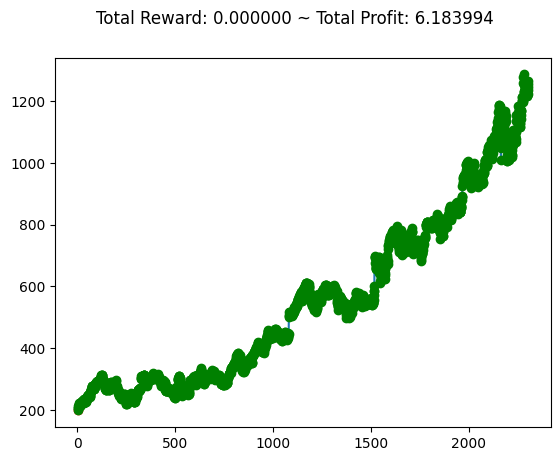

In [9]:
render_single_episode(make_offline_env(), offline_agent)

## Evaluate the Offline-Trained Agent in the Online Chronos Environment.
The agent trained on offline embeddings can be evaluated in the online environment without any code changes. The two Chronos workflows are designed to be interchangeable at the environment level, so you can train with one and test with the other seamlessly.

This is specially useful for real-world applications where you might want to precompute embeddings for faster training iterations, but still want to deploy the agent in an environment that computes embeddings on the fly.

In [10]:
from crosslearn import REINFORCE, make_vec_env
from crosslearn.extractors import ChronosExtractor

# Assume you already trained the offline agent (as shown in the notebook)
#    (pre-compute embeddings once with build_offline_bundle -> OfflineStocksEnv -> REINFORCE)
# offline_agent = REINFORCE(vec_offline, n_steps=512, seed=42, verbose=2)
# offline_agent.learn(total_timesteps=10_000)   # or however many you used

# 1.1. Define the *online* environment (raw rolling OHLCV windows) and
# 1.2. Create a fresh REINFORCE instance configured for *online* Chronos
#    (no learning — we only need the policy for inference)
online_agent = REINFORCE(
    make_vec_env(make_online_env, n_envs=1),   # online environment with raw windows
    n_steps=512,                               # dummy value, not used for eval
    features_extractor_class=ChronosExtractor,
    features_extractor_kwargs={
        "feature_names": FEATURE_COLUMNS,
        "selected_columns": SELECTED_COLUMNS,
        # match whatever you used in build_offline_bundle (pooling, etc.)
    },
    seed=42,
    verbose=2,
)

# 2. Transfer the learned weights (MLP + actor head)
#    ChronosExtractor has no learnable parameters that conflict with the offline case
online_agent.policy.load_state_dict(
    offline_agent.policy.state_dict(),
    strict=False
)

REINFORCE | n_envs=1 | device=cpu | obs=(30, 5) | actions=2
ActorCriticPolicy(
  extractor=ChronosExtractor(model_name='amazon/chronos-2', lookback=30, n_features=5, selected_indices=[3, 4], embedding_dim=768, features_dim=768),
  shared=Sequential(
  (0): Linear(in_features=768, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
),
  actor=Linear(in_features=64, out_features=2, bias=True),
  critic=Linear(in_features=64, out_features=1, bias=True)
)


<All keys matched successfully>

Info: {'total_reward': 0.0, 'total_profit': np.float64(6.1839935904214185), 'position': <Positions.Long: 1>}


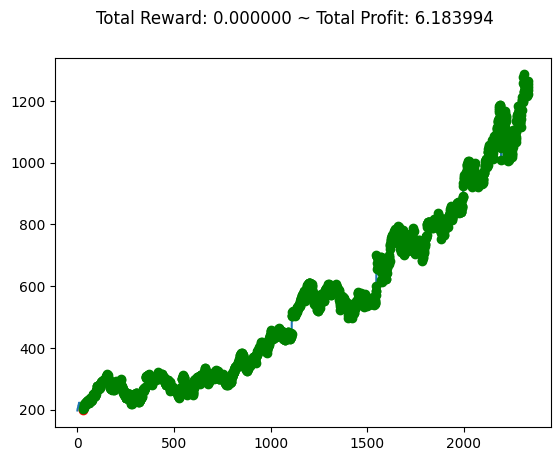

In [11]:
# 3. Evaluate / render in the online Chronos environment
online_env = make_online_env()
render_single_episode(online_env, online_agent)